In [16]:
import torch
from torchvision import datasets, models, transforms
import torch.nn as nn
import torch.optim as optim
import json
from PIL import Image
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import time

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
data_dir = '/content/drive/MyDrive/Image Classi/flowers'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'
test_dir = data_dir + '/test'

In [19]:
#Defining means and standard deviations for normalization:
means=[0.485,0.456,0.406]
stdevs=[0.229,0.224,0.225]
#Defining a sequence of transformations:
train_transforms =transforms.Compose([
    #This transformation preforms rotation of all images in range from -30 to +30 degrees.
    #This is done to enable model to "understand" object orienations in the real world thus allowing it to generalize better.
    transforms.RandomRotation(30),
    #This transformation preforms a random crop of the image and then resizes it to 224 x 224 pixels.
    #This is done to ensure that the model "sees" different parts of the image durring the training, what in turn allows the model to learn
    #about features that are unrelated to the objects postion
    #224x224 pixels are used because it is the size required by pretrained network
    transforms.RandomResizedCrop(224),
    #This transformation flips image horizontaly with probability of 0.5 % what helps model to learn about features that are unrelated to
    #the left-right orienation of the object. Not all images will be flipped, prob of 0.5% means that each image has a 50% chance of being flipped.
    #The images to be flipped are chosen randomly and this randomness is needed because flipping every image may introduce bias into the training data.
    transforms.RandomHorizontalFlip(),
    #This transformation converts the image to tensor as nn will take that tensor as input for processing
    transforms.ToTensor(),
    #Below performs normalization of means and stdevs to ensure that the pixel values have a similar scale.
    transforms.Normalize(mean=means,std=stdevs)
    ])
#Defining sequence for validation and test transformations as they use the same parameteres
val_test_transforms = transforms.Compose([
    #This transformation resizes the image to a square of size 255x255
    #The image size is larger than the model has been trained on and that is to provide model with more spatial information
    #What would improve it's preformance
    transforms.Resize(255),
    #This transformation crops the center of the image to a size of 224x224 pixels.To ensure that the image has the desired dimensions for input.
    transforms.CenterCrop(224),
    #This transformation converts the image to tensor as nn will take that tensor as input for processing
    transforms.ToTensor(),
    #Below performs normalization of means and stdevs to ensure that the pixel values have a similar scale.
    transforms.Normalize(mean=means, std=stdevs)
])

#Loading the dataset with ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(valid_dir, transform=val_test_transforms )
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)
# Definining the dataloaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)

In [20]:
#Loading in a mapping from category label to category name
with open('/content/drive/MyDrive/Image Classi/cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f)

In [21]:
#Below line defines the start time varaible to record the starting time of training
start_time = time.time()

#Loading pretrained SqueezeNet model
model = models.squeezenet1_1(pretrained=True)

#Below line of code freezes the convolutional layers in order to prevent their weights from being updated when I am training classifier layers.
#Need to do that since I want to retain features that network has learned during pretraining.
for param in model.parameters():
    param.requires_grad = False

#Below modifies the final convolutional layer of the classifier to match the number of classes from my category file.
model.classifier[1] = nn.Conv2d(512, len(cat_to_name), kernel_size=(1, 1), stride=(1, 1))
model.num_classes = len(cat_to_name)

#Below defines loss function. CrossEntropyLoss is commonly used for classification tasks like these.
#This function outputs a probability distribution and then measures it against the true target labels.
criterion = nn.CrossEntropyLoss()

#Below line defines optimizer function. I chose ADAM optimizer.
#Adam is an adaptive learning rate optimization algorithm that optimizes the above loss function to help it "learn".
#In each training iteration adam computes gradients (partial derivatives) for the loss function with respect to each parameter.
#To make sure we are going towards the minimum adam calculates average of previous gradients (it looks at their mean and variance).
optimizer = optim.Adam(model.parameters(),0.001)

#This line of code moves model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#Below trains model for 5 epochs
epochs = 5
for epoch in range(epochs):
    epoch_start_time = time.time() #this line of code records the starting time of the epoch
    print(f"Epoch {epoch+1}/{epochs}")
    print("-" * 10)

    model.train()

    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        #Forward pass. Input data is fed into the model to compute probability distribution.
        outputs = model(inputs)
        #Loss function now calculates the loss between probability distribution and targed labels.
        loss = criterion(outputs, labels)

        #Backpropogation. Gradients of the loss function with respect to the model parameters are
        #now computed using automatic differentiation and learning rate is adjusted
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    #Prit out statistics  for review
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Training Loss: {epoch_loss:.4f}")

    #Calculates and prints out the time taken for the current epoch
    epoch_end_time = time.time()
    epoch_time = epoch_end_time - epoch_start_time
    minutes = int(epoch_time // 60)
    seconds = int(epoch_time % 60)

    print(f"Time taken for epoch {epoch+1}:{minutes} minutes {seconds} seconds")
    print()

#Records the total training time and prints it out
end_time = time.time()
total_training_time = end_time - start_time
total_minutes = int(total_training_time // 60)
total_seconds = int(total_training_time % 60)
print(f"Total training time: {total_minutes} minutes {total_seconds} seconds")
print("Training complete")

Epoch 1/5
----------
Training Loss: 2.9152
Time taken for epoch 1:7 minutes 33 seconds

Epoch 2/5
----------
Training Loss: 1.1460
Time taken for epoch 2:7 minutes 33 seconds

Epoch 3/5
----------
Training Loss: 0.7786
Time taken for epoch 3:7 minutes 32 seconds

Epoch 4/5
----------
Training Loss: 0.6358
Time taken for epoch 4:7 minutes 28 seconds

Epoch 5/5
----------
Training Loss: 0.5551
Time taken for epoch 5:7 minutes 31 seconds

Total training time: 37 minutes 39 seconds
Training complete


In [22]:
#Below line of code sets model to evaluation stage
model.eval()

#Below variables are initialized to track accuracy of the model
correct = 0
total = 0

#Below line disables the backpropogation
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #Forward pass. Input data is fed into the model to compute probability distribution for validation dataset
        outputs = model(inputs)

        #Below line gets the predicted labels
        _, predicted = torch.max(outputs.data, 1)

        #Below line updates the total number of images
        total += labels.size(0)

        #Below line Update number of correct predictions
        correct += (predicted == labels).sum().item()

#Below line calculates the accuracy precentage
accuracy = 100 * correct / total
print(f'Accuracy on the validation set: {accuracy:.2f}%')

Accuracy on the validation set: 91.56%


In [23]:
#Below line defines file path for checkpoint
checkpoint_path = 'checkpoint.pth'

#Below defines what needs to be saved in the checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),  #This saves the model parameters
    'class_to_idx': train_dataset.class_to_idx,  #This saves mapping of classes to indices
}

#This line saves the checkpoint
torch.save(checkpoint, checkpoint_path)

In [24]:
#This function loads the checkpoint
def load_checkpoint(filepath):

    checkpoint = torch.load(filepath)

    #below rebuilds model architecture
    model = models.squeezenet1_0(pretrained=True)
    model.classifier[1] = torch.nn.Conv2d(512, len(checkpoint['class_to_idx']), kernel_size=(1,1), stride=(1,1))
    model.load_state_dict(checkpoint['model_state_dict'])
    #below attaches the class to checkpoint
    model.class_to_idx = checkpoint['class_to_idx']

    return model

In [25]:
def process_image(image):
    '''
    This function scales, resizes and normalizes the image and returns numpy array
    '''
    #Below defines transformations
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=means, std=stdevs)
    ])

    #Below code opens the image, applies transformation and converts img to numpy array
    img = Image.open(image)
    img_tensor = preprocess(img)
    img_np = np.array(img_tensor)

    return img_np

In [26]:
#Below code display's image
def imshow(image, ax=None, title=None):

    if ax is None:
        fig, ax = plt.subplots()

    # PyTorch tensors assume the color channel is the first dimension
    # but matplotlib assumes is the third dimension
    image = image.transpose((1, 2, 0))

    #Below undoes preprocessing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean

    # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    image = np.clip(image, 0, 1)

    ax.imshow(image)

    return ax


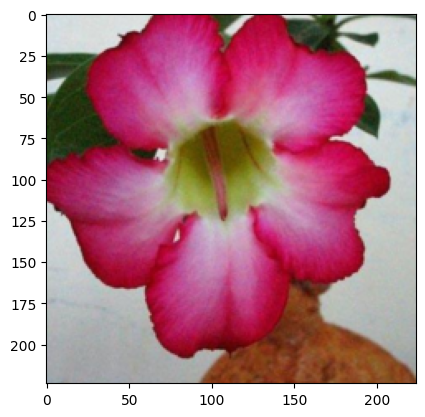

In [27]:
def test_images():
    #Gets list of image file paths in the test folder
    image_files = [os.path.join(test_dir, category, img)
                   for category in os.listdir(test_dir)
                   for img in os.listdir(os.path.join(test_dir, category))]

    #Below Selects 1 random images from test folder to display
    random_images = random.sample(image_files, 1)

    #Display's each image that has been selected
    for img_path in random_images:
        imshow(process_image(img_path))

#Calls the function
test_images()

In [28]:
def predict(image_path, model, topk=5):
    ''' This function predict classes of an image using model
        Parameters:
          image_path (str): path to the image file.
          model: model that has been trained
          topk (int): number of top k most probable classes to display.
    '''
    #Below loads the checkpoint
    checkpoint = torch.load('checkpoint.pth')

    #This code loads the model state dictionary
    model.load_state_dict(checkpoint['model_state_dict'])

    #This code gets the mapping of classes to indices
    class_to_idx = checkpoint['class_to_idx']

    #This line calls the process_image function
    image = process_image(image_path)

    #This line converts the image to tensor and adds batch dimension
    image = torch.unsqueeze(torch.from_numpy(image), 0)

    #This moves the tensor to the cuda device if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image = image.to(device)

    #This sets model to evaluation mode
    model.eval()

    #Forward pass. Now input data is fed into the model to compute probability distribution for test dataset
    with torch.no_grad():
        output = model(image)

    #Below line of code calculates the probabilites and topk classes
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probabilities, top_classes = probabilities.topk(topk)

    #This line of code inverts the class_to_idx dictionary and converts the top-K cass indices
    #to their respective class labels using the inverted dictionary. This is done to convert output of neural network
    #to something that can be interpreted
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    top_classes = [idx_to_class[idx.item()] for idx in top_classes]

    return top_probabilities, top_classes

In [29]:
def display_prediction(image_path, model, cat_to_name, topk=5):
    ''' This function displays an image along with the topk predicted classes and their probabilities.

    Parameters:
        image_path (str): path to the image file.
        model: model that has been trained
        cat_to_name (dict): mapping from category label to category name.
        topk (int): number of top k most probable classes to display.
    '''
    #This line of code gets topk probabilities and class indices
    top_probabilities, top_indices = predict(image_path, model, topk=topk)

    #This line maps the class indices to class labels using cat_to_name dictionary
    top_classes = [cat_to_name[str(idx)] for idx in top_indices]

    #This line loads and display the image
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    #This plots the topk classes and probabilities
    plt.figure(figsize=(8, 5))
    plt.barh(range(len(top_classes)), top_probabilities, color='blue')
    plt.yticks(range(len(top_classes)), top_classes)
    plt.gca().invert_yaxis() # This inverts the y-axis to display top class at the top
    plt.xlabel('Probability')
    plt.ylabel('Class')
    plt.title('Top 5 Predicted Classes')
    plt.show()

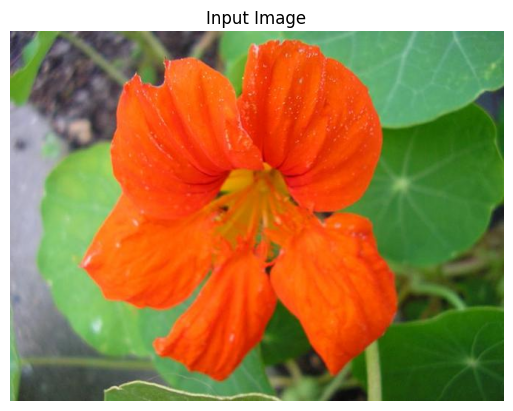

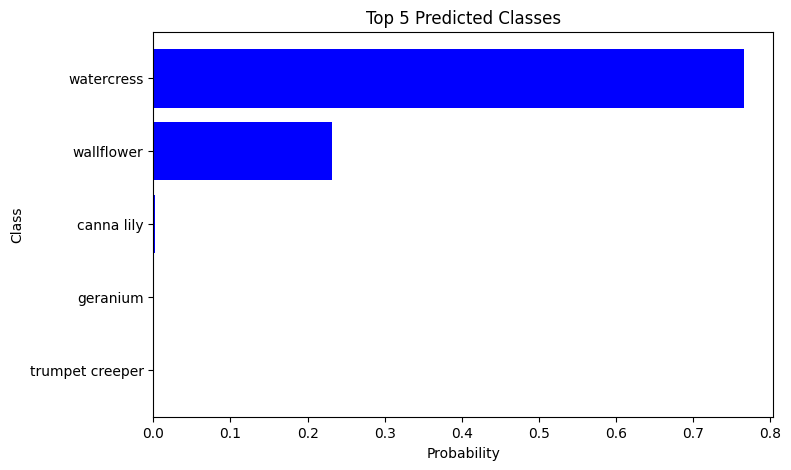

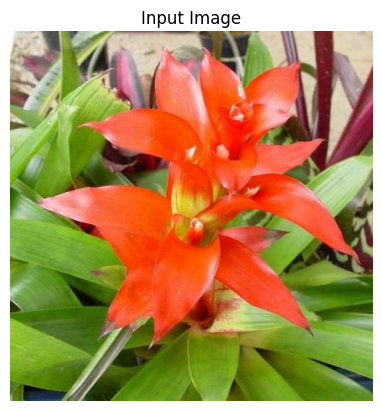

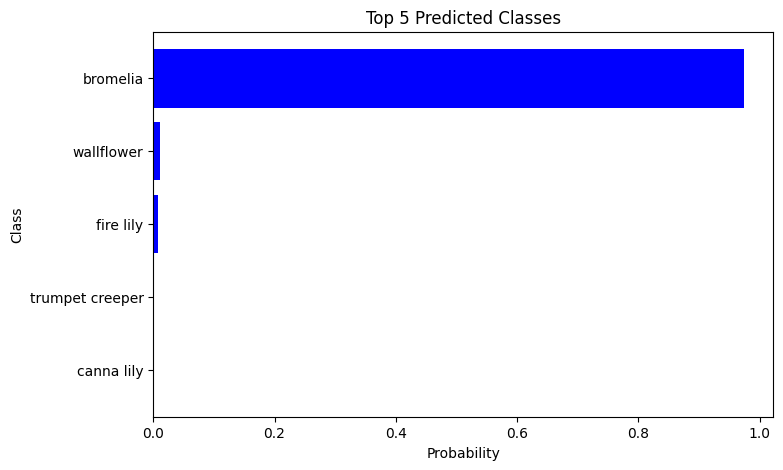

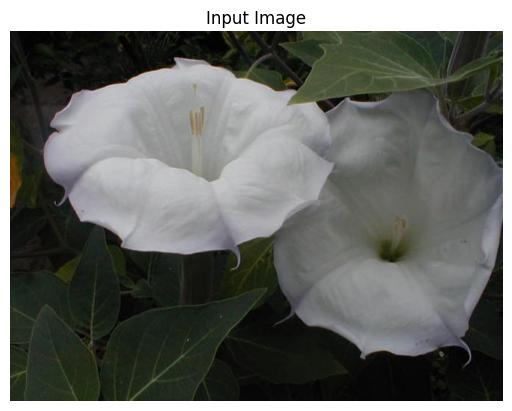

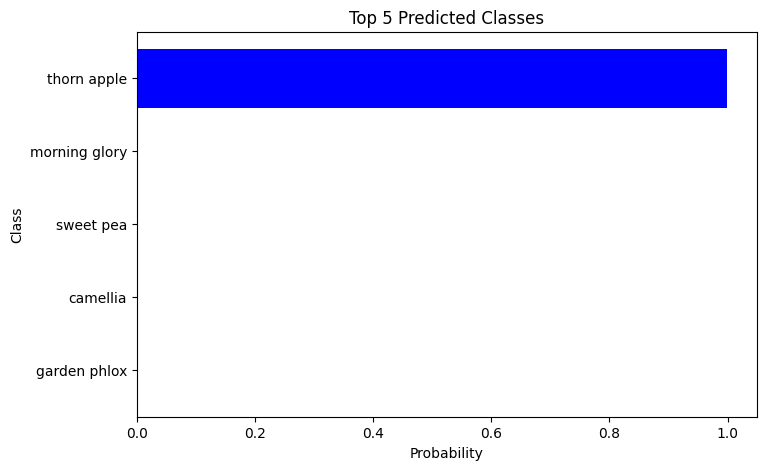

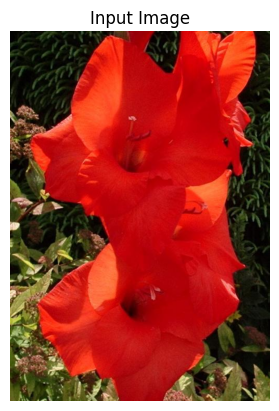

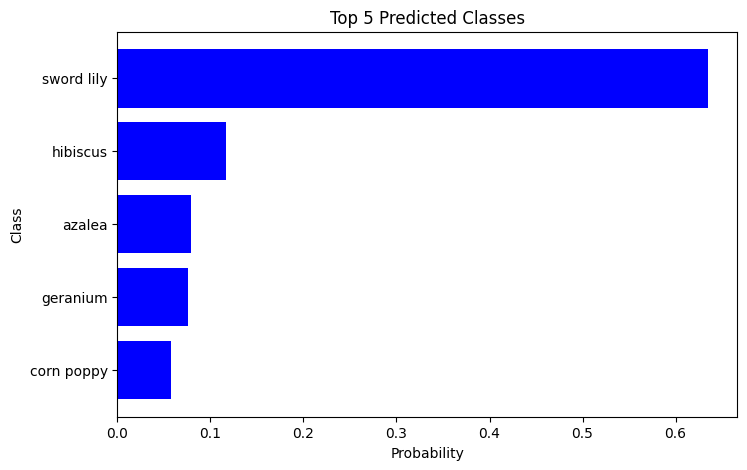

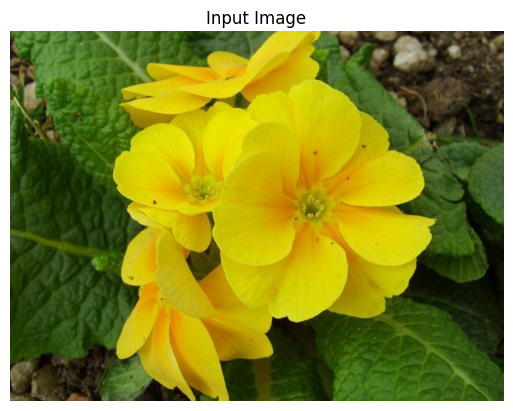

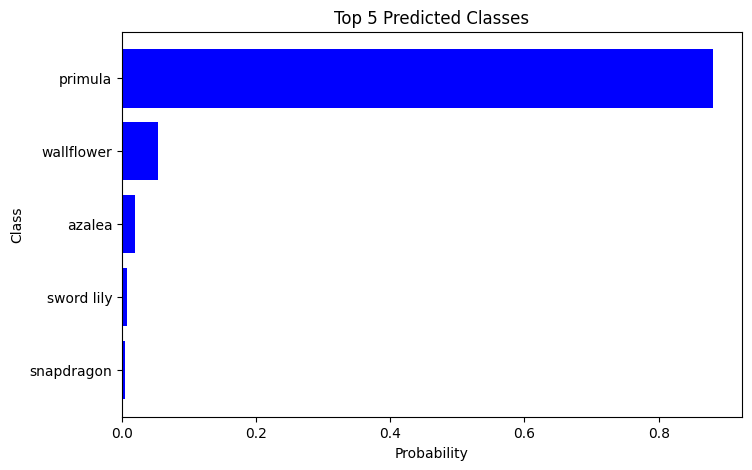

In [30]:
def test_prediction(model, topk=5):

    #Gets list of image file paths in the test folder
    image_files = [os.path.join(test_dir, category, img)
                   for category in os.listdir(test_dir)
                   for img in os.listdir(os.path.join(test_dir, category))]

    #Selects 5 random images for testing
    random_images = random.sample(image_files, 5)

    #Displaya each random image along with predictions
    for img_path in random_images:
        display_prediction(img_path, model, cat_to_name, topk)

#Calls the function on model
test_prediction(model)